Saving salaries.csv to salaries.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98034 entries, 0 to 98033
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           98034 non-null  int64 
 1   experience_level    98034 non-null  object
 2   employment_type     98034 non-null  object
 3   job_title           98034 non-null  object
 4   salary              98034 non-null  int64 
 5   salary_currency     98034 non-null  object
 6   salary_in_usd       98034 non-null  int64 
 7   employee_residence  98034 non-null  object
 8   remote_ratio        98034 non-null  int64 
 9   company_location    98034 non-null  object
 10  company_size        98034 non-null  object
dtypes: int64(4), object(7)
memory usage: 8.2+ MB
None
Removing outliers from salary column using IQR...


<ipython-input-1-a0e5c511ab27>:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # Fill missing values using forward fill
<ipython-input-1-a0e5c511ab27>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['z_score'] = (df['salary'] - df['salary'].mean()) / df['salary'].std()


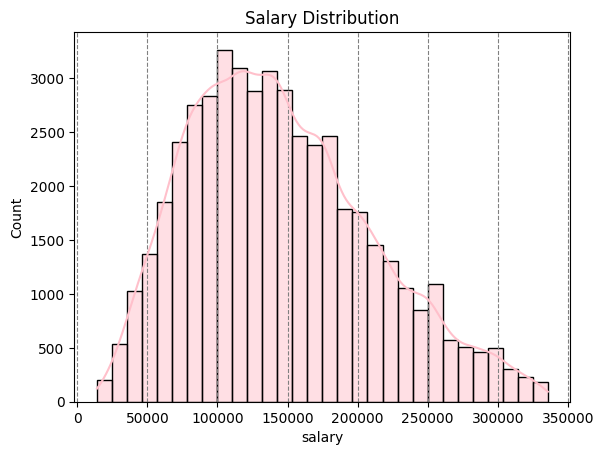

<ipython-input-1-a0e5c511ab27>:65: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='experience_level', y='salary', data=df,color='pink',ci=None)


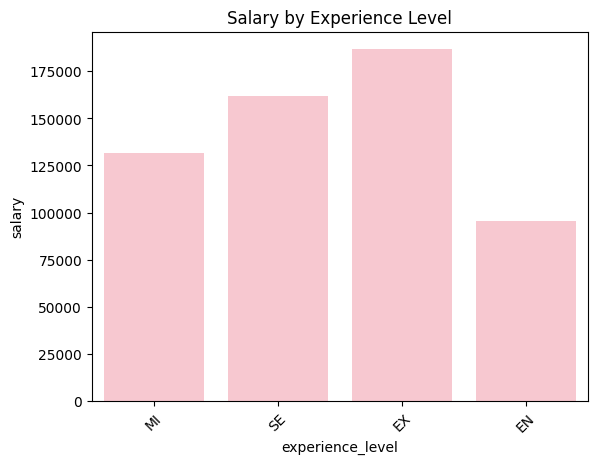

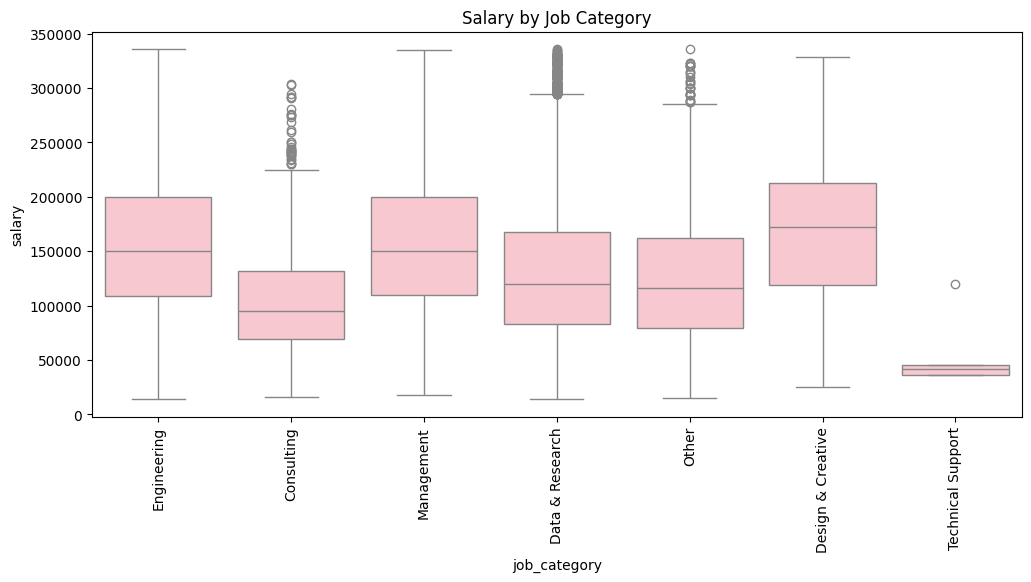

<ipython-input-1-a0e5c511ab27>:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='company_location', y='salary', data=df,color='pink',ci=None)


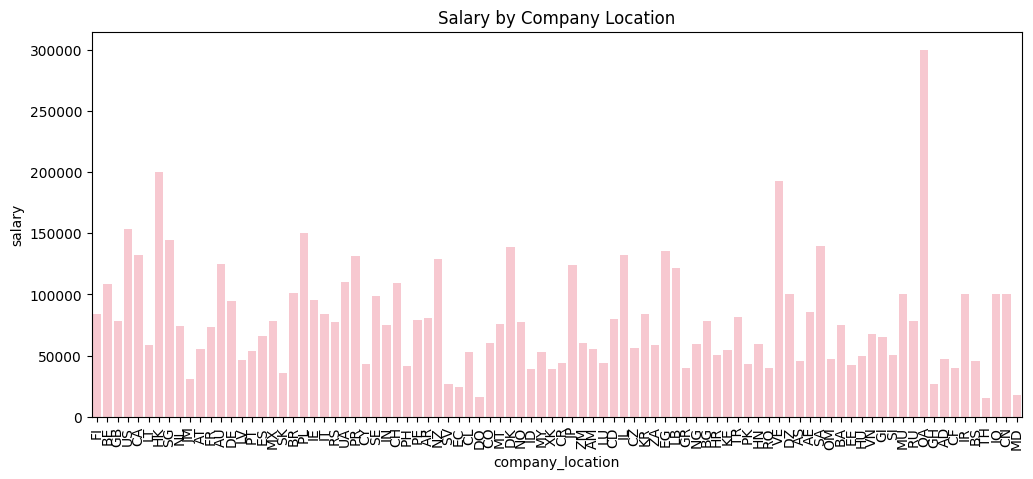

Calculated Z-scores for salary within each experience level.
Insights:
- Experience level affects salaries significantly.
- Salaries vary widely across job categories and locations.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]  # Get uploaded filename
df = pd.read_csv(file_name)

#display basic info
print(df.info())  # Check data types and missing values

# Data Cleaning
df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True)  # Fill missing values using forward fill

# Outlier Detection & Removal using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

if 'salary' in df.columns:
    print("Removing outliers from salary column using IQR...")
    df = remove_outliers(df, 'salary')

# Outlier Detection using Z-score
if 'salary' in df.columns:
    df['z_score'] = (df['salary'] - df['salary'].mean()) / df['salary'].std()
    df = df[df['z_score'].abs() <= 3]  # Keep values within 3 standard deviations
    df.drop(columns=['z_score'], inplace=True)

# Grouping Job Titles
def categorize_job_title(title):
    title = title.lower()
    if any(word in title for word in ['engineer', 'developer', 'programmer', 'software', 'architect']):
        return 'Engineering'
    elif any(word in title for word in ['manager', 'lead', 'head', 'director', 'supervisor']):
        return 'Management'
    elif any(word in title for word in ['analyst', 'scientist', 'researcher', 'statistician', 'economist']):
        return 'Data & Research'
    elif any(word in title for word in ['designer', 'artist', 'illustrator', 'ux', 'ui']):
        return 'Design & Creative'
    elif any(word in title for word in ['consultant', 'advisor', 'specialist', 'strategist']):
        return 'Consulting'
    elif any(word in title for word in ['technician', 'operator', 'mechanic', 'support']):
        return 'Technical Support'
    else:
        return 'Other'

df['job_category'] = df['job_title'].apply(categorize_job_title)

# Exploratory Data Analysis (EDA)
sns.histplot(df['salary'], bins=30, kde=True,color='pink')
plt.title("Salary Distribution")
plt.grid(axis='x',color='gray',linestyle='--')  # Add grid to salary distribution plot
plt.show()

if 'experience_level' in df.columns:
    sns.barplot(x='experience_level', y='salary', data=df,color='pink',ci=None)
    plt.xticks(rotation=45)
    plt.title("Salary by Experience Level")
    plt.show()

if 'job_category' in df.columns:
    plt.figure(figsize=(12, 5))
    sns.boxplot(x='job_category', y='salary', data=df, color='pink')
    plt.xticks(rotation=90)
    plt.title("Salary by Job Category")
    plt.show()

if 'company_location' in df.columns:
    plt.figure(figsize=(12, 5))
    sns.barplot(x='company_location', y='salary', data=df,color='pink',ci=None)
    plt.xticks(rotation=90)
    plt.title("Salary by Company Location")
    plt.show()

# Statistical Analysis
if 'experience_level' in df.columns:
    df['z_score_experience'] = (df['salary'] - df.groupby('experience_level')['salary'].transform('mean')) / df.groupby('experience_level')['salary'].transform('std')
    print("Calculated Z-scores for salary within each experience level.")

# Conclusion
print("Insights:")
print("- Experience level affects salaries significantly.")
print("- Salaries vary widely across job categories and locations.")